In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm

In [5]:
states = ["Walking","Running","Resting"]

transition_matrix = np.array([
    [0.6,0.3,0.1],  
    [0.2,0.5,0.3],
    [0.3,0.2,0.5]
])

print("\nTransition Matrix:")
print(transition_matrix)


Transition Matrix:
[[0.6 0.3 0.1]
 [0.2 0.5 0.3]
 [0.3 0.2 0.5]]


In [7]:
def simulate_markov_chain(start_state, n_steps=20):
    current_state = states.index(start_state)
    sequence = [start_state]
    for _ in range(n_steps):
        current_state = np.random.choice([0, 1,2], p=transition_matrix[current_state])
        sequence.append(states[current_state])
    return sequence

mc_sequence = simulate_markov_chain("Walking", 15)
print("\nGenerated Markov Chain Sequence:")
print(mc_sequence)


Generated Markov Chain Sequence:
['Walking', 'Running', 'Running', 'Running', 'Walking', 'Walking', 'Walking', 'Resting', 'Resting', 'Resting', 'Walking', 'Walking', 'Running', 'Running', 'Resting', 'Running']


In [18]:
hidden_states = ["Walking", "Running","Resting"]
observations = ["Low", "Medium","High"]

model = hmm.MultinomialHMM(n_components=3, n_iter=50)
model.transmat_ = np.array([
    [0.6,0.3,0.1],
    [0.2,0.5,0.3],
    [0.3,0.2,0.5]
])
model.emissionprob_ = np.array([
    [0.6, 0.3,0.1],  
    [0.1, 0.3,0.6],
    [0.7,0.2,0.1]
])
model.startprob_ = np.array([0.5, 0.3,0.2])

print("\nTransition Matrix (Hidden States):")
print(model.transmat_)
print("\nEmission Matrix:")
print(model.emissionprob_)

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Transition Matrix (Hidden States):
[[0.6 0.3 0.1]
 [0.2 0.5 0.3]
 [0.3 0.2 0.5]]

Emission Matrix:
[[0.6 0.3 0.1]
 [0.1 0.3 0.6]
 [0.7 0.2 0.1]]


In [11]:
%pip install hmmlearn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
model.n_trials = 1
obs_seq, hidden_seq = model.sample(15)

obs_seq = obs_seq.flatten()
hidden_seq = hidden_seq.flatten()

decoded_obs = [observations[i] for i in obs_seq]
decoded_hidden = [hidden_states[i] for i in hidden_seq]

print("\nGenerated Observations from HMM:")
print(decoded_obs)
print("\nActual Hidden States from HMM:")
print(decoded_hidden)




Generated Observations from HMM:
['Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low']

Actual Hidden States from HMM:
['Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Resting', 'Walking', 'Walking', 'Running', 'Running']


In [20]:
n_observations = len(observations)
X_decoded = np.zeros((len(obs_seq), n_observations))
X_decoded[np.arange(len(obs_seq)), obs_seq] = 1

logprob, predicted_states = model.decode(X_decoded, algorithm="viterbi")
decoded_predicted = [hidden_states[i] for i in predicted_states]

print("\nPredicted Hidden States (Viterbi):")
print(decoded_predicted)


Predicted Hidden States (Viterbi):
['Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking']


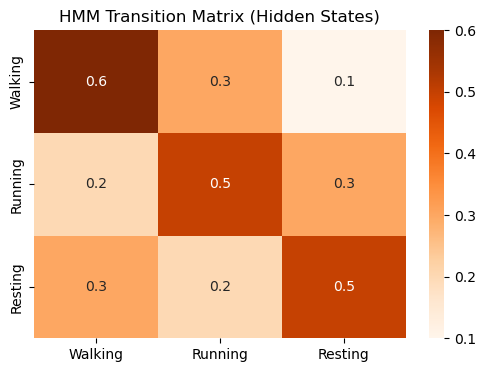

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(model.transmat_, annot=True, cmap="Oranges",
            xticklabels=hidden_states, yticklabels=hidden_states)
plt.title("HMM Transition Matrix (Hidden States)")
plt.show()